## DATA AVAILABLE -
#  This book has the following sheets:
#   Customer Acquisition: At the time of card issuing, company maintains the details of customers.
##  Spend (Transaction data): Credit card spend for each customer
##  Repayment: Credit card Payment done by customer
##  Following are some of Mr. Watson’s questions to a Consultant (like you) to understand the 
## customers spend & repayment behavior.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
repayment = pd.read_csv('Repayment.csv')
spend = pd.read_csv('Spend.csv')
customer_acquisition = pd.read_csv('Customer Acqusition.csv')

In [76]:
customer_spend = pd.merge(left=customer_acquisition,right=spend,on="Customer",how="inner")

In [77]:
customer_repayment = pd.merge(left=customer_acquisition,right=repayment,on="Customer",how="inner")

In [78]:
customer_repayment

,No,Customer,Age,City,Product,Limit,Company,Segment,SL No:,Month,Amount,Unnamed: 4
0,1,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed,NaN,12-Jan-04,495414.75,NaN
1,1,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed,2.0,3-Jan-04,245899.02,NaN
2,1,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed,3.0,15-Jan-04,259490.06,NaN
3,1,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed,4.0,25-Jan-04,437555.12,NaN
4,1,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed,5.0,17-Jan-05,165972.88,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1495,96,A96,54,CHENNAI,Silver,100000.0,C19,Salaried_Pvt,98.0,25-Jan-04,310992.30,NaN
1496,97,A97,58,TRIVANDRUM,Platimum,10000.0,C20,Govt,99.0,12-Jan-04,121874.90,NaN
1497,98,A98,51,CALCUTTA,Platimum,10001.0,C21,Normal Salary,100.0,3-Jan-04,337815.57,NaN
1498,99,A99,35,CALCUTTA,Platimum,10002.0,C22,Self Employed,101.0,15-Jan-04,25682.73,NaN


## 1. In the above dataset,
 # a. In case age is less than 18, replace it with mean of age values.
 # b. In case spend amount is more than the limit, replace it with 50% of that customer’s limit. 
#     (customer’s limit provided in acquisition table is the per transaction limit on his card)
 #    c. Incase the repayment amount is more than the limit, replace the repayment with the limit.

In [79]:
# a. In case age is less than 18, replace it with mean of age values.
customer_acquisition.loc[(customer_acquisition.Age<18),'Age']=customer_acquisition.Age.mean()
customer_acquisition.Age

C:\Users\vivek\AppData\Local\Temp\ipykernel_12076\1921301461.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '46.49' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  customer_acquisition.loc[(customer_acquisition.Age<18),'Age']=customer_acquisition.Age.mean()


0     76.0
1     71.0
2     34.0
3     47.0
4     56.0
      ... 
95    54.0
96    58.0
97    51.0
98    35.0
99    36.0
Name: Age, Length: 100, dtype: float64

In [80]:
# b. In case spend amount is more than the limit, replace it with 50% of that customer’s limit.
customer_spend.loc[customer_spend["Amount"] > customer_spend["Limit"],"Amount"] = (50 * customer_spend["Limit"])/100
customer_spend.Amount

0       485470.80
1       410556.13
2        23740.46
3       484342.47
4       369694.07
          ...    
1495     54729.66
1496      5000.00
1497      5000.50
1498      5001.00
1499     50000.00
Name: Amount, Length: 1500, dtype: float64

In [81]:
# c. Incase the repayment amount is more than the limit, replace the repayment with the limit.
customer_repayment.loc[customer_repayment["Amount"] > customer_repayment["Limit"],"Amount"] = customer_repayment["Limit"]
customer_repayment.Amount

0       495414.75
1       245899.02
2       259490.06
3       437555.12
4       165972.88
          ...    
1495    100000.00
1496     10000.00
1497     10001.00
1498     10002.00
1499     69551.19
Name: Amount, Length: 1500, dtype: float64

# 2. From the above dataset create the following summaries:
# a. How many distinct customers exist?
# b. How many distinct categories exist?
# c. What is the average monthly spend by customers?
 # d. What is the average monthly repayment by customers?
# e. If the monthly rate of interest is 2.9%, what is the profit for the bank for each month? (Profit is defined as interest earned on Monthly Profit. Monthly Profit = Monthly repayment – Monthly spend. Interest is earned only on positive profits and not on negative amounts)
# f. What are the top 5 product types?
# g. Which city is having maximum spend?
# h. Which age group is spending more money?
# i. Who are the top 10 customers in terms of repayment

In [82]:
# a. How many distinct customers exist?
customer_acquisition['Customer'].drop_duplicates().count()

np.int64(100)

In [83]:
# b. How many distinct categories exist?
customer_acquisition['Product'].drop_duplicates().count()

np.int64(3)

In [84]:
# c.c. What is the average monthly spend by customers?
monthly_spend=customer_spend.groupby(['Customer','Month'])['Amount'].mean().reset_index(name='Monthly_spend')
monthly_spend

,Customer,Month,Monthly_spend
0,A1,1-Feb-05,23370.20
1,A1,12-Jan-04,463017.01
2,A1,15-Jan-04,23740.46
3,A1,17-Jan-05,369694.07
4,A1,19-Apr-06,346925.68
...,...,...,...
1252,A95,15-Jan-04,240401.50
1253,A96,25-Jan-04,54729.66
1254,A97,12-Jan-04,5000.00
1255,A98,3-Jan-04,5000.50


In [85]:
# d. What is the average monthly repayment by customers?
mothly_repayment=customer_repayment.groupby(['Customer','Month'])['Amount'].mean().reset_index(name='Monthlay_repayment')
mothly_repayment

,Customer,Month,Monthlay_repayment
0,A1,1-Apr-06,429099.970
1,A1,1-Feb-05,14473.410
2,A1,12-Jan-04,422930.785
3,A1,15-Jan-04,356258.850
4,A1,16-Feb-05,187398.640
...,...,...,...
1276,A95,15-Jan-04,369405.960
1277,A96,25-Jan-04,100000.000
1278,A97,12-Jan-04,10000.000
1279,A98,3-Jan-04,10001.000


In [86]:
# e. If the monthly rate of interest is 2.9%, what is the profit for the bank for each month? (Profit is defined 
#    as interest earned on Monthly Profit. Monthly Profit = Monthly repayment – 
#    Monthly spend. Interest is earned only on positive profits and not on negative amounts)

data=pd.merge(monthly_spend,mothly_repayment,how='inner')
data['Monthly_profit']=data['Monthlay_repayment']-data['Monthly_spend']
data['bank_profit']=data['Monthly_profit'].apply(lambda x:x*0.029 if x>0 else 0)
data

,Customer,Month,Monthly_spend,Monthlay_repayment,Monthly_profit,bank_profit
0,A1,1-Feb-05,23370.20,14473.410,-8896.790,0.00000
1,A1,12-Jan-04,463017.01,422930.785,-40086.225,0.00000
2,A1,15-Jan-04,23740.46,356258.850,332518.390,9643.03331
3,A1,17-Jan-05,369694.07,165972.880,-203721.190,0.00000
4,A1,19-Apr-06,346925.68,79849.190,-267076.490,0.00000
...,...,...,...,...,...,...
488,A95,15-Jan-04,240401.50,369405.960,129004.460,3741.12934
489,A96,25-Jan-04,54729.66,100000.000,45270.340,1312.83986
490,A97,12-Jan-04,5000.00,10000.000,5000.000,145.00000
491,A98,3-Jan-04,5000.50,10001.000,5000.500,145.01450


In [87]:
# f. What are the top 5 product types?
spend.groupby('Type')['Amount'].sum().nlargest(n=5).reset_index()

,Type,Amount
0,PETRO,49863174.09
1,CAMERA,41481571.96
2,FOOD,37773338.43
3,TRAIN TICKET,33067077.15
4,AIR TICKET,32955445.42


In [88]:
# g. Which city is having maximum spend?
customer_spend.groupby('City')['Amount'].sum().nlargest(1)

City
COCHIN    45963513.5
Name: Amount, dtype: float64

In [89]:
# h. Which age group is spending more money?
df=customer_spend
df['Age_Group'] = ''

# Assign age groups using a for loop
for i in range(len(df)):
    age = df.loc[i, 'Age']
    
    if age < 18:
        df.loc[i, 'Age_Group'] = '<18'
    elif age < 25:
        df.loc[i, 'Age_Group'] = '18-24'
    elif age < 35:
        df.loc[i, 'Age_Group'] = '25-34'
    elif age < 50:
        df.loc[i, 'Age_Group'] = '35-49'
    else:
        df.loc[i, 'Age_Group'] = '50+'

print(df)

##
df.groupby('Age_Group')['Amount'].sum().nlargest(1)

       No Customer  Age        City   Product     Limit Company  \
0       1       A1   76   BANGALORE      Gold  500000.0      C1   
1       1       A1   76   BANGALORE      Gold  500000.0      C1   
2       1       A1   76   BANGALORE      Gold  500000.0      C1   
3       1       A1   76   BANGALORE      Gold  500000.0      C1   
4       1       A1   76   BANGALORE      Gold  500000.0      C1   
...   ...      ...  ...         ...       ...       ...     ...   
1495   96      A96   54     CHENNAI    Silver  100000.0     C19   
1496   97      A97   58  TRIVANDRUM  Platimum   10000.0     C20   
1497   98      A98   51    CALCUTTA  Platimum   10001.0     C21   
1498   99      A99   35    CALCUTTA  Platimum   10002.0     C22   
1499  100     A100   36      COCHIN    Silver  100000.0      C5   

            Segment  Sl No:      Month        Type     Amount Age_Group  
0     Self Employed       1  12-Jan-04   JEWELLERY  485470.80       50+  
1     Self Employed       2   3-Jan-04       PE

Age_Group
50+    80796314.96
Name: Amount, dtype: float64

In [90]:
# i. Who are the top 10 customers in terms of repayment
customer_repayment = pd.merge(left=customer_acquisition,right=repayment,on="Customer",how="inner")
customer_repayment.groupby('Customer')['Amount'].sum().nlargest(n=10).reset_index()

,Customer,Amount
0,A61,10539142.91
1,A60,9876290.74
2,A13,9572000.66
3,A22,9372561.68
4,A21,9056336.15
5,A43,8489871.46
6,A45,8448334.87
7,A12,8334760.16
8,A48,8292416.75
9,A14,7943268.63


#  3. Calculate the city wise spend on each product on yearly basis. Also include a graphical representation for the same.


<Axes: xlabel='City'>

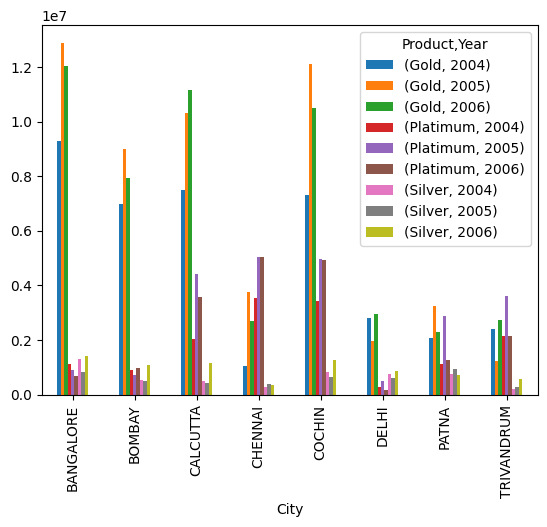

In [93]:

df=customer_spend.pivot_table(index='City',columns=['Product','Year'],values='Amount',aggfunc='sum').plot(kind='bar')
df

In [92]:
customer_spend['Month'] = pd.to_datetime(customer_spend['Month'], errors='coerce')
customer_spend['Year'] = customer_spend['Month'].dt.year

C:\Users\vivek\AppData\Local\Temp\ipykernel_12076\2047737532.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  customer_spend['Month'] = pd.to_datetime(customer_spend['Month'], errors='coerce')


In [95]:
customer_spend['Month_name'] = customer_spend['Month'].dt.month

# 4. Create graphs for
#  a. Monthly comparison of total spends, city wise
#  b. Comparison of yearly spend on air tickets
#  c. Comparison of monthly spend for each product (look for any seasonality that exists in terms of spend

<Axes: xlabel='City'>

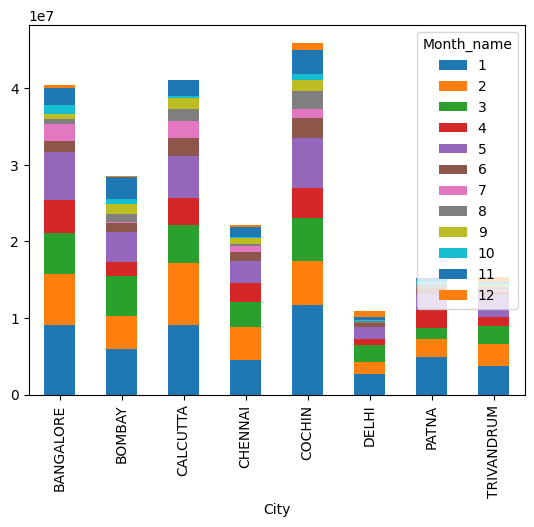

In [96]:
# a. Monthly comparison of total spends, city wise
pd.pivot_table(data = customer_spend, index = 'City', columns='Month_name', 
               values='Amount', aggfunc='sum').plot(kind='bar',stacked=True)

<Axes: xlabel='Type'>

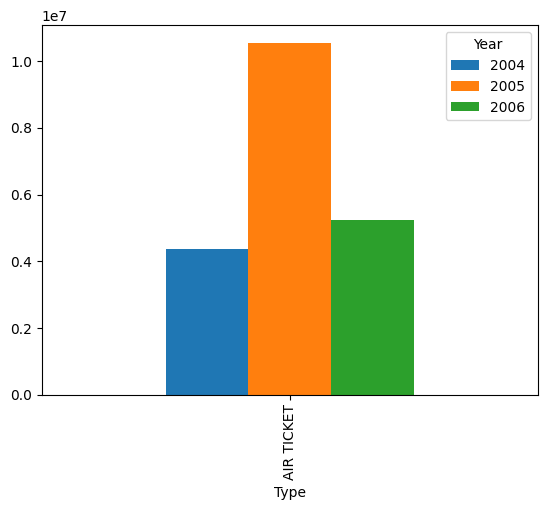

In [97]:
# b. Comparison of yearly spend on air tickets

pd.pivot_table(data = customer_spend[customer_spend.Type=='AIR TICKET'], index = 'Type', columns='Year', 
               values='Amount', aggfunc='sum').plot(kind='bar')

<Axes: xlabel='Product'>

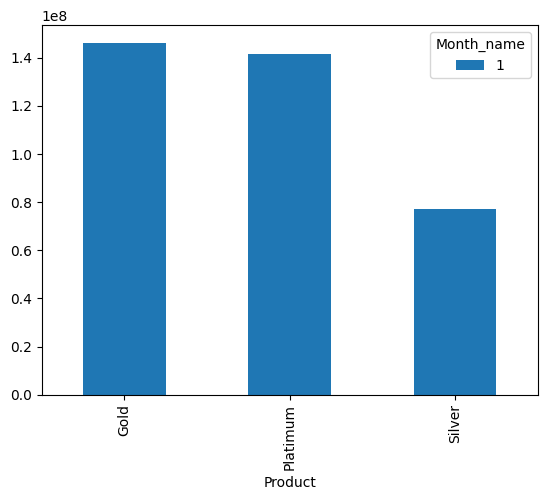

In [71]:
# c. Comparison of monthly spend for each product (look for any seasonality that exists in terms of spend)

pd.pivot_table(data = customer_spend, index = 'Product', columns='Month_name', 
               values='Amount', aggfunc='sum').plot(kind='bar')

## 5. Write user defined PYTHON function to perform the following analysis:You need to find top 10 customers for each city in terms of their repayment amount by different products and by different time periods i.e. year or month. The user should be able to specify the product (Gold/Silver/Platinum) and time period (yearly or monthly) and the function should automatically take these inputs while identifying the top 10 customers

In [52]:
def top10_cust(customer_repayment, product_type, time_period):
    
    df = customer_repayment.copy()
    
    df.columns = df.columns.str.strip()
    
    # Clean columns
    df['Product'] = df['Product'].str.strip().str.lower()
    
    # Convert Month
    df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
    
    # Filter (exact match now works)
    df = df[df['Product'] == product_type.lower()]
    
    # Remove null dates
    df = df.dropna(subset=['Month'])
    
    # Time period
    if time_period.lower() == 'yearly':
        df['Time_Period'] = df['Month'].dt.year
    elif time_period.lower() == 'monthly':
        df['Time_Period'] = df['Month'].dt.to_period('M')
    else:
        raise ValueError("Use 'yearly' or 'monthly'")
    
    # Group
    df_grouped = df.groupby(['City', 'Customer', 'Time_Period'])['Amount'].sum().reset_index()
    
    # Sort
    df_grouped = df_grouped.sort_values(['City', 'Time_Period', 'Amount'], ascending=[True, True, False])
    
    # Top 10
    top10 = df_grouped.groupby(['City', 'Time_Period']).head(10)
    
    return top10

result = top10_cust(customer_repayment, 'Gold', 'yearly')
print(result)

          City Customer  Time_Period      Amount
6    BANGALORE      A14         2004  2770261.30
0    BANGALORE       A1         2004  2359797.84
3    BANGALORE      A13         2004  2337012.77
12   BANGALORE      A43         2004  1906497.47
9    BANGALORE      A30         2004   978777.17
..         ...      ...          ...         ...
81       PATNA      A26         2006  3330421.30
83       PATNA      A66         2006   113094.58
85  TRIVANDRUM      A28         2004   965108.49
86  TRIVANDRUM      A28         2005  2827009.82
87  TRIVANDRUM      A28         2006  3376614.65

[88 rows x 4 columns]


C:\Users\vivek\AppData\Local\Temp\ipykernel_12076\2504065351.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Month'] = pd.to_datetime(df['Month'], errors='coerce')


In [54]:
# Top 10 customers for each Product category
df = customer_repayment.copy()

df['Product'] = df['Product'].str.strip()
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')

# Group by Product and Customer
df_grouped = df.groupby(['Product', 'Customer'])['Amount'].sum().reset_index()

# Sort by Product and Amount
df_grouped = df_grouped.sort_values(['Product', 'Amount'], ascending=[True, False])

# Top 10 per Product
top10 = df_grouped.groupby('Product').head(10)

print(top10)

     Product Customer       Amount
21      Gold      A61  10539142.91
20      Gold      A60   9876290.74
4       Gold      A13   9572000.66
17      Gold      A43   8489871.46
19      Gold      A45   8448334.87
3       Gold      A12   8334760.16
5       Gold      A14   7943268.63
18      Gold      A44   7744730.12
16      Gold      A42   7615460.86
9       Gold      A26   7254687.09
40  Platimum      A21   9056336.15
53  Platimum      A48   8292416.75
48  Platimum      A39   7622483.30
45  Platimum      A36   7574765.88
46  Platimum      A37   7535804.83
47  Platimum      A38   7470956.35
52  Platimum      A47   7286876.96
50  Platimum      A40   6990749.27
54  Platimum      A49   6907115.36
60  Platimum      A54   5575582.12
73    Silver      A22   9372561.68
77    Silver      A46   7861541.41
74    Silver      A23   6695551.74
76    Silver      A25   6649292.89
75    Silver      A24   5958277.62
71    Silver      A18   5309969.03
92    Silver       A8   5278278.84
80    Silver      A5

C:\Users\vivek\AppData\Local\Temp\ipykernel_12076\673456943.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Month'] = pd.to_datetime(df['Month'], errors='coerce')


In [74]:
customer_spend['Month_name'].unique()

array([1], dtype=int32)